In [4]:
import sys
from pathlib import Path

# Agregar carpeta raíz del proyecto al path
sys.path.append(
    str(Path().resolve().parent)
)

# Metricas

In [6]:
from src.entrenamiento.kmeans import df, kmeans, X_escalado
from sklearn.metrics import silhouette_score

# ===============================
# SILHOUETTE SCORE
# ===============================

score = silhouette_score(
    X_escalado,
    df['Cluster']
)

print(f"Silhouette Score: {score:.3f}")

# ===============================
# INERCIA
# ===============================

print(f"\nInercia: {kmeans.inertia_}")

# ===============================
# DISTRIBUCIÓN DE CLUSTERS
# ===============================

cantidad = df['Cluster'].value_counts()

print("\nCantidad por cluster:")
print(cantidad)

# ===============================
# PORCENTAJE POR CLUSTER
# ===============================

porcentaje = (
    df['Cluster']
    .value_counts(normalize=True)
    *100
)

print("\nPorcentaje por cluster:")
print(porcentaje.round(2))

Silhouette Score: 0.088

Inercia: 16941523.229838457

Cantidad por cluster:
Cluster
0    420
2    407
1    373
Name: count, dtype: int64

Porcentaje por cluster:
Cluster
0    35.00
2    33.92
1    31.08
Name: proportion, dtype: float64


# Graficos

## Visualización de clusters encontrados

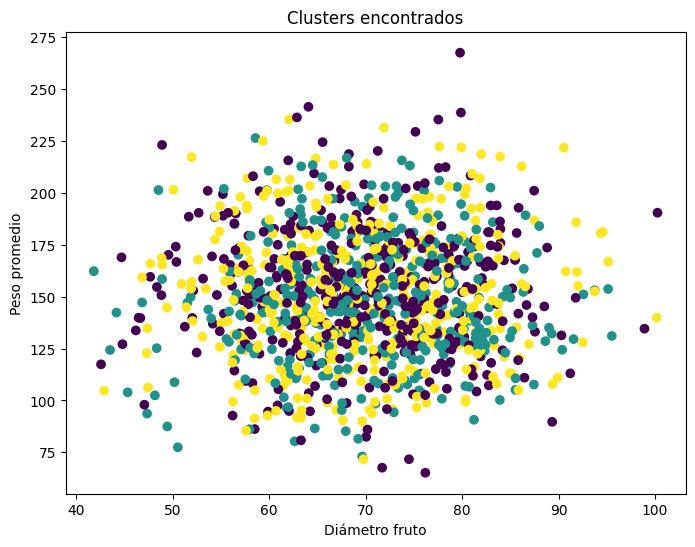

In [8]:
from src.entrenamiento.kmeans import df
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['diametro_fruto'],
    df['peso_promedio'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Diámetro fruto")
plt.ylabel("Peso promedio")
plt.title("Clusters encontrados")

plt.show()

## Método del codo

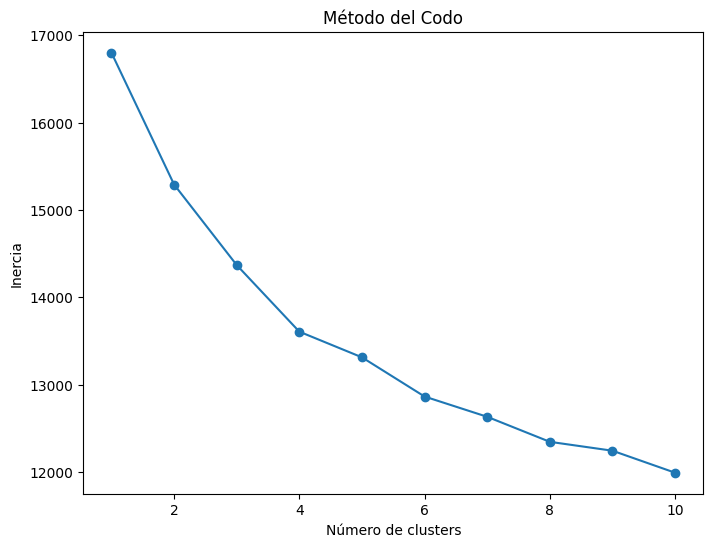

In [9]:
from src.entrenamiento.kmeans import X_escalado
from sklearn.cluster import KMeans

inercia=[]

for k in range(1,11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42
    )

    modelo.fit(X_escalado)

    inercia.append(
        modelo.inertia_
    )

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    inercia,
    marker='o'
)

plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")

plt.show()

## Distribución de registros por cluster

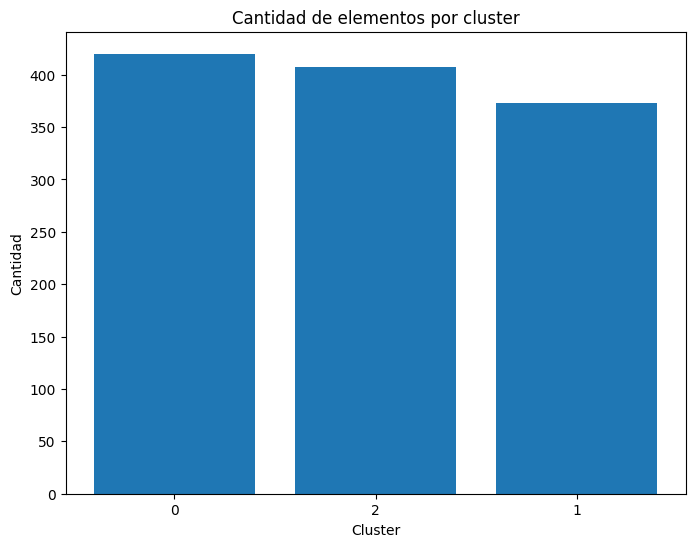

In [11]:
cantidad = df['Cluster'].value_counts()

plt.figure(figsize=(8,6))

plt.bar(
    cantidad.index.astype(str),
    cantidad.values
)

plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.title("Cantidad de elementos por cluster")

plt.show()

## Comparación con target_calidad

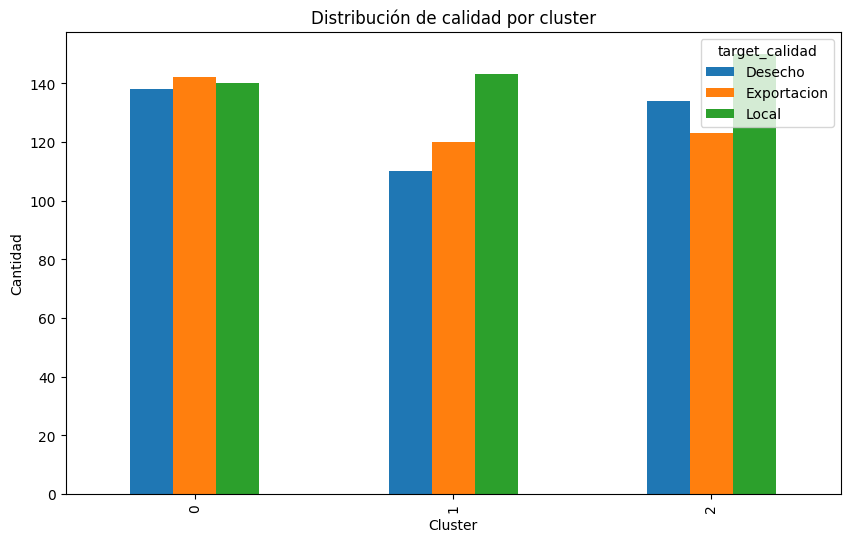

In [13]:
import pandas as pd

comparacion = pd.crosstab(
    df['Cluster'],
    df['target_calidad']
)

comparacion.plot(
    kind='bar',
    figsize=(10,6)
)

plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.title("Distribución de calidad por cluster")

plt.show()

# Resultados

## Promedios por cluster

In [15]:
resumen = df.groupby('Cluster')[[
    'ph_suelo',
    'nitrogeno',
    'fosforo',
    'potasio',
    'humedad_suelo',
    'diametro_fruto',
    'peso_promedio'
]].mean()

print("Promedios por cluster:")
display(resumen)

Promedios por cluster:


,ph_suelo,nitrogeno,fosforo,potasio,humedad_suelo,diametro_fruto,peso_promedio
Cluster,,,,,,,
0,6.794699,81.043233,51.484345,103.253761,44.983242,69.594501,153.121687
1,6.728138,79.965851,54.337573,104.449839,45.772171,70.177204,148.012323
2,6.732834,80.277610,51.733540,103.113463,47.282024,69.545171,150.870020


## Comparación con variable objetivo

In [20]:
import pandas as pd

comparacion = pd.crosstab(
    df['Cluster'],
    df['target_calidad']
)

print("Distribución de calidad por cluster:")
display(comparacion)

Distribución de calidad por cluster:


target_calidad,Desecho,Exportacion,Local
Cluster,,,
0,138,142,140
1,110,120,143
2,134,123,150


## Distribución de registros por cluster

In [23]:
cantidad = df['Cluster'].value_counts()

print("Cantidad de elementos por cluster:")
display(cantidad)


porcentaje = (
    df['Cluster']
    .value_counts(normalize=True)
    *100
)

print("Porcentaje por cluster:")
display(porcentaje.round(2))

Cantidad de elementos por cluster:


Cluster
0    420
2    407
1    373
Name: count, dtype: int64

Porcentaje por cluster:


Cluster
0    35.00
2    33.92
1    31.08
Name: proportion, dtype: float64

## Comparación entre modelo sin escalar y modelo escalado

In [26]:
cambios = (
    df['Cluster_SinEscalar']
    !=
    df['Cluster']
).sum()

porcentaje = cambios / len(df) * 100

print(f"Registros que cambiaron de cluster: {cambios}")
print(f"Porcentaje de cambios: {porcentaje:.2f}%")

Registros que cambiaron de cluster: 806
Porcentaje de cambios: 67.17%


## Etiquetado de clusters

In [27]:
# ===============================
# CREAR ETIQUETAS DE CLUSTERS
# ===============================

nombres_clusters = {
    0: "Grupo Agrícola A",
    1: "Grupo Agrícola B",
    2: "Grupo Agrícola C"
}

# ===============================
# ASIGNAR ETIQUETAS
# ===============================

df['Perfil_Cultivo'] = df['Cluster'].map(
    nombres_clusters
)

display(
    df[[
        'Cluster',
        'Perfil_Cultivo'
    ]].head(10)
)



,Cluster,Perfil_Cultivo
0,2,Grupo Agrícola C
1,0,Grupo Agrícola A
2,2,Grupo Agrícola C
3,2,Grupo Agrícola C
4,0,Grupo Agrícola A
5,2,Grupo Agrícola C
6,0,Grupo Agrícola A
7,1,Grupo Agrícola B
8,2,Grupo Agrícola C
9,1,Grupo Agrícola B


In [29]:
# ===============================
# EXTRAER GRUPOS
# ===============================

grupo_a = df[
    df['Perfil_Cultivo']=="Grupo Agrícola A"
]

grupo_b = df[
    df['Perfil_Cultivo']=="Grupo Agrícola B"
]

grupo_c = df[
    df['Perfil_Cultivo']=="Grupo Agrícola C"
]

print(f"Grupo Agrícola A: {len(grupo_a)} registros")
print(f"Grupo Agrícola B: {len(grupo_b)} registros")
print(f"Grupo Agrícola C: {len(grupo_c)} registros")

Grupo Agrícola A: 420 registros
Grupo Agrícola B: 373 registros
Grupo Agrícola C: 407 registros
